<a href="https://colab.research.google.com/github/gagikgasparyann/EDA-DS120/blob/main/ds_group_project_AA(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
# import os
# os.chdir('/home/ranlinus/Desktop')

df = pd.read_csv("NYC_Motor_Vehicle_Collisions_to_Person.csv")

In [82]:
df.head()

,CRASH_DATE,CRASH_TIME,PERSON_INJURY,PERSON_AGE,BODILY_INJURY,SAFETY_EQUIPMENT,PERSON_SEX,PERSON_TYPE,PED_LOCATION,CONTRIBUTING_FACTOR_2,...,COMPLAINT,EMOTIONAL_STATUS,VEHICLE_ID,PERSON_ID,CONTRIBUTING_FACTOR_1,POSITION_IN_VEHICLE,PED_ROLE,UNIQUE_ID,PED_ACTION,COLLISION_ID
0,2021-05-02,21:00,Killed,62.0,Head,NaN,F,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian at Inter...,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,...,Severe Bleeding,Apparent Death,NaN,f2f329b6-2dfc-4bd0-b751-2e4255f1ea06,Traffic Control Disregarded,NaN,Pedestrian,11791937,Crossing Against Signal,4412948
1,2021-05-21,0:00,Killed,24.0,Entire Body,Air Bag Deployed,M,Occupant,NaN,NaN,...,Internal,Apparent Death,19986231.0,e27e12a2-0485-4e22-b692-3f8a765d2582,NaN,Driver,Driver,11819198,NaN,4419608
2,2021-10-15,2:00,Killed,30.0,Head,NaN,M,Occupant,NaN,NaN,...,Internal,Apparent Death,20091024.0,1a6f5aa7-5125-4be2-8499-fe7977cb0d90,NaN,Driver,Driver,11998317,NaN,4467504
3,2021-04-17,13:00,Killed,71.0,Head,NaN,M,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian Not at I...,Unspecified,...,Internal,Unconscious,NaN,b950706b-00a4-485c-84c5-777208cc3cc9,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,NaN,Pedestrian,11745791,"Crossing, No Signal, or Crosswalk",4408062
4,2021-05-25,22:00,Killed,69.0,Entire Body,NaN,F,Pedestrian,Pedestrian/Bicyclist/Other Pedestrian Not at I...,Unspecified,...,None Visible,Conscious,NaN,6504ea0a-c92d-444c-8127-284943be9aac,Unspecified,NaN,Pedestrian,11991283,"Crossing, No Signal, Marked Crosswalk",4420918


# **1. Data Cleaning**


1.1. Checking for duplicates

In [83]:
df.duplicated().sum()

np.int64(0)

1.2. Checking for NaN values

In [84]:
df.isnull().sum()

,0
CRASH_DATE,0
CRASH_TIME,0
PERSON_INJURY,0
PERSON_AGE,421
BODILY_INJURY,0
SAFETY_EQUIPMENT,12177
PERSON_SEX,0
PERSON_TYPE,0
PED_LOCATION,39098
CONTRIBUTING_FACTOR_2,39123


1.3. Correcting columns one by one

1.3.1. Column **"PERSON_AGE"**


In [85]:
print(f"Column 'PERSON_AGE'")

df['PERSON_AGE'] = df['PERSON_AGE'].fillna(df["PERSON_AGE"].mean()).round()
print (f"Verifying 0 null values in the 'PERSON_AGE' column: \nnull values in the column:{df['PERSON_AGE'].isnull().sum()}")
# print(f"Unique values:{df['PERSON_AGE'].nunique()}")

Column 'PERSON_AGE'
Verifying 0 null values in the 'PERSON_AGE' column: 
null values in the column:0


1.3.2. Column **"SAFETY_EQUIPMENT"**

In [86]:
print(f"\nColumn 'SAFETY_EQUIPMENT'")

df['SAFETY_EQUIPMENT'] = df['SAFETY_EQUIPMENT'].fillna('Unknown')
print (f"Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: \nnull values in the column:{df['SAFETY_EQUIPMENT'].isnull().sum()}")
# print(f"Unique values:{df['SAFETY_EQUIPMENT'].nunique()}")


Column 'SAFETY_EQUIPMENT'
Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: 
null values in the column:0


1.3.3. Column **"PED_LOCATION"**

In [87]:
print(f"\nColumn 'PED_LOCATION'")

df['PED_LOCATION'] = df['PED_LOCATION'].fillna('Does Not Apply')
df['PED_LOCATION'] = df['PED_LOCATION'].replace('Unknown', 'Does Not Apply')
# print(df.PED_LOCATION.unique().tolist())
print (f"Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: \nnull values in the column:{df['PED_LOCATION'].isnull().sum()}")
# print(f"Unique values:{df['PED_LOCATION'].nunique()}")


Column 'PED_LOCATION'
Verifying 0 null values in the 'SAFETY_EQUIPMENT' column: 
null values in the column:0


1.3.4 & 1.3.5 Columns **"CONTRIBUTING_FACTOR_1"** and **"CONTRIBUTING_FACTOR_2"**

In [88]:
df['CONTRIBUTING_FACTOR_1'] = df['CONTRIBUTING_FACTOR_1'].fillna('Does Not Apply')
df['CONTRIBUTING_FACTOR_1'] = df['CONTRIBUTING_FACTOR_1'].replace('Unspecified', 'Does Not Apply')

# To view the repeating contributing 1 factors, run
# pd.Series(df['CONTRIBUTING_FACTOR_1'].unique())

df['CONTRIBUTING_FACTOR_2'] = df['CONTRIBUTING_FACTOR_2'].fillna('Does Not Apply')
df['CONTRIBUTING_FACTOR_2'] = df['CONTRIBUTING_FACTOR_2'].replace('Unspecified', 'Does Not Apply')

# To view the repeating contributing 2 factors, run
# pd.Series(df['CONTRIBUTING_FACTOR_2'].unique())

1.3.6. Column **"PED_ACTION"**

In [89]:
df['PED_ACTION'] = df['PED_ACTION'].fillna('Does Not Apply')
df['PED_ACTION'] = df['PED_ACTION'].replace('Unknown', 'Does Not Apply')

# To view the repeating values for the PED_ACTION column, run
# pd.Series(df.PED_ACTION.unique().tolist())

1.3.7. Column **"POSITION_IN_VEHICLE"**

In [90]:
df["POSITION_IN_VEHICLE"] = df["POSITION_IN_VEHICLE"].fillna("Does Not Apply")
df["POSITION_IN_VEHICLE"] = df["POSITION_IN_VEHICLE"].replace("Unknown", "Does Not Apply")

# To view the repeating values for the POSITION_IN_VEHICLE column, run
# pd.Series(df.PED_ACTION.unique().tolist())

1.3.8. Column **"EJECTION"**

Fill the missing values with the mode of the column, which in this case is the **"Not Ejected"** value taking more than 78% of occurences in the column values

In [91]:
# df.EJECTION.value_counts()[0]/df.shape[0] * 100
# df.EJECTION.value_counts()

df['EJECTION'] = df['EJECTION'].fillna('Not Ejected')
# df.EJECTION.value_counts()

# additional possibly important information / code used in process
# df.EJECTION.isnull().sum()
# pd.Series(df.EJECTION.unique().tolist())
# df.EJECTION.mode()

In [92]:
df["EMOTIONAL_STATUS"] = df['EMOTIONAL_STATUS'].replace("Unknown", "Does Not Apply")
pd.Series(df.EMOTIONAL_STATUS.unique())

,0
0,Apparent Death
1,Unconscious
2,Conscious
3,Shock
4,Semiconscious
5,Does Not Apply
6,Incoherent


1.3.9. Column **"VEHICLE_ID"**

In [93]:
df["VEHICLE_ID"] = df["VEHICLE_ID"].fillna("Does Not Apply")
df["VEHICLE_ID"] = df["VEHICLE_ID"].replace("Unknown", "Does Not Apply")

# To view the repeating values for the POSITION_IN_VEHICLE column, run
# (df.VEHICLE_ID.unique().tolist())

### 🎉 **OUR DATASET IS CLEAN** !!!

In [94]:
df.isnull().sum()

,0
CRASH_DATE,0
CRASH_TIME,0
PERSON_INJURY,0
PERSON_AGE,0
BODILY_INJURY,0
SAFETY_EQUIPMENT,0
PERSON_SEX,0
PERSON_TYPE,0
PED_LOCATION,0
CONTRIBUTING_FACTOR_2,0


1.4. Several adjustments for the finally clean dataset

1.4.1. Check data types

In [95]:
df.dtypes

,0
CRASH_DATE,object
CRASH_TIME,object
PERSON_INJURY,object
PERSON_AGE,float64
BODILY_INJURY,object
SAFETY_EQUIPMENT,object
PERSON_SEX,object
PERSON_TYPE,object
PED_LOCATION,object
CONTRIBUTING_FACTOR_2,object


1.4.2. Transform **"CRASH_DATE"** and **"CRASH_TIME"** into a more applicable data type, and

1.4.3. Merge them into **"CRASH_DATE_TIME"** to make the further analysis more effective.

We will remove the crash_date and crash_time columns later, before starting(see 1.4.7).

In [96]:
df['CRASH_DATE_TIME'] = df['CRASH_DATE'] + ' ' + df['CRASH_TIME']
pd.to_datetime(df.CRASH_DATE_TIME)
df['CRASH_DATE_TIME'] = pd.to_datetime(df.CRASH_DATE_TIME)
df['CRASH_DATE_TIME']

,CRASH_DATE_TIME
0,2021-05-02 21:00:00
1,2021-05-21 00:00:00
2,2021-10-15 02:00:00
3,2021-04-17 13:00:00
4,2021-05-25 22:00:00
...,...
45664,2021-05-07 00:00:00
45665,2021-04-27 13:00:00
45666,2021-05-07 14:00:00
45667,2021-05-10 16:00:00


Additional checking for correct values

1.4.4. Check for the values of **"PERSON_SEX"** column

1.4.5 Check for the values of **"BODILY_INJURY"** column


In [97]:
print(df.PERSON_SEX.unique())
print(df.BODILY_INJURY.unique())

['F' 'M' 'U']
['Head' 'Entire Body' 'Chest' 'Unknown' 'Abdomen - Pelvis' 'Back'
 'Knee-Lower Leg Foot' 'Neck' 'Does Not Apply' 'Shoulder - Upper Arm'
 'Elbow-Lower-Arm-Hand' 'Face' 'Hip-Upper Leg' 'Eye']


1.4.6. Removing all **"PERSON_AGE"** values which are out of logic

In [98]:
print((df['PERSON_AGE'] < 0).sum())
df.loc[df['PERSON_AGE'] < 0, 'PERSON_AGE'] = np.nan
df.loc[df['PERSON_AGE'] > 99, 'PERSON_AGE'] = np.nan

df['PERSON_AGE'].describe().round(2)

15


,PERSON_AGE
count,45633.00
mean,36.78
std,16.48
min,0.00
25%,25.00
50%,34.00
75%,48.00
max,99.00


After this we went back and re-run 1.3.1 to fill all the nan values with "Unknown"-s

1.4.7. **Hide unnecessary columns for data analysis**
- Hiding **ID**-s because they simly enumerate the cases, and
- hiding **CRASH_DATE** and **CRASH_TIME** because we've created a single **CRASH_DATE_TIME** column, combining both.

In [99]:
analysis_df = df.drop(columns = ["VEHICLE_ID", "PERSON_ID", "UNIQUE_ID", "COLLISION_ID", "CRASH_DATE", "CRASH_TIME"])

In [100]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45669 entries, 0 to 45668
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   CRASH_DATE             45669 non-null  object        
 1   CRASH_TIME             45669 non-null  object        
 2   PERSON_INJURY          45669 non-null  object        
 3   PERSON_AGE             45633 non-null  float64       
 4   BODILY_INJURY          45669 non-null  object        
 5   SAFETY_EQUIPMENT       45669 non-null  object        
 6   PERSON_SEX             45669 non-null  object        
 7   PERSON_TYPE            45669 non-null  object        
 8   PED_LOCATION           45669 non-null  object        
 9   CONTRIBUTING_FACTOR_2  45669 non-null  object        
 10  EJECTION               45669 non-null  object        
 11  COMPLAINT              45669 non-null  object        
 12  EMOTIONAL_STATUS       45669 non-null  object        
 13  V

1.5. Logic errors

Here, as you can see, we have recorded helmet on an Bicyclist, lap beld on a pedestrian, and so on.

We will correct those logical errors now

In [101]:
df.groupby('PERSON_TYPE')['SAFETY_EQUIPMENT'].value_counts()

PERSON_TYPE      SAFETY_EQUIPMENT                        
Bicyclist        Unknown                                      3131
                 Helmet Only (In-Line Skater/Bicyclist)        812
                 Helmet/Other (In-Line Skater/Bicyclist)       229
                 Helmet (Motorcycle Only)                      155
                 Other                                          92
                 Lap Belt & Harness                             30
                 Lap Belt                                        6
                 Pads Only (In-Line Skater/Bicyclist)            4
                 Stoppers Only (In-Line Skater/Bicyclist)        3
                 Harness                                         2
Occupant         Lap Belt & Harness                          18134
                 Unknown                                      8090
                 Lap Belt                                     3693
                 Air Bag Deployed/Lap Belt/Harness             926
                 Helmet (Motorcycle Only)                      835
                 Child Restraint Only                          490
                 Air Bag Deployed                              261
                 Air Bag Deployed/Lap Belt                     145
                 Other                                         104
                 Harness                                       101
                 Helmet Only (In-Line Skater/Bicyclist)         59
                 Helmet/Other (In-Line Skater/Bicyclist)        35
                 Air Bag Deployed/Child Restraint               26
                 Pads Only (In-Line Skater/Bicyclist)            3
                 Stoppers Only (In-Line Skater/Bicyclist)        1
Other Motorized  Unknown                                      1380
                 Helmet (Motorcycle Only)                      212
                 Helmet Only (In-Line Skater/Bicyclist)        174
                 Helmet/Other (In-Line Skater/Bicyclist)        61
                 Other                                          28
                 Lap Belt & Harness                             15
                 Lap Belt                                       11
                 Pads Only (In-Line Skater/Bicyclist)            4
                 Harness                                         1
                 Stoppers Only (In-Line Skater/Bicyclist)        1
Pedestrian       Unknown                                      6394
                 Other                                           9
                 Lap Belt & Harness                              5
                 Helmet (Motorcycle Only)                        3
                 Helmet Only (In-Line Skater/Bicyclist)          2
                 Helmet/Other (In-Line Skater/Bicyclist)         1
                 Lap Belt                                        1
Name: count, dtype: int64

The actual code for correcting logic errors.

Note that it is important to go back to 1.3.2. to make all NaN values "Unknown" again.

In [102]:
# Bicyclist
df.loc[(df.PERSON_TYPE == "Bicyclist") & (df.SAFETY_EQUIPMENT.isin([
                                                                    'Lap Belt','Harness','Lap Belt & Harness', 'Helmet (Motorcycle Only)'
                                                                    ])), 'SAFETY_EQUIPMENT'] = np.nan

# Occupant
df.loc[(df.PERSON_TYPE == "Occupant") & (df.SAFETY_EQUIPMENT.isin([
                                                                    'Helmet (Motorcycle Only)', 'Helmet Only (In-Line Skater/Bicyclist)',
                                                                    'Helmet/Other (In-Line Skater/Bicyclist)','Pads Only (In-Line Skater/Bicyclist)',
                                                                    'Stoppers Only (In-Line Skater/Bicyclist)'
                                                                    ])), 'SAFETY_EQUIPMENT'] = np.nan
# Other Motorized
df.loc[(df.PERSON_TYPE == "Other Motorized") & (df.SAFETY_EQUIPMENT.isin([
                                                                    'Helmet Only (In-Line Skater/Bicyclist)', 'Helmet/Other (In-Line Skater/Bicyclist)',
                                                                    ])), 'SAFETY_EQUIPMENT'] = np.nan
# Pedestrian
df.loc[(df.PERSON_TYPE == "Pedestrian") & (df.SAFETY_EQUIPMENT.isin([
                                                                    'Lap Belt','Harness','Lap Belt & Harness', 'Helmet (Motorcycle Only)',
                                                                    'Helmet Only (In-Line Skater/Bicyclist)', 'Helmet/Other (In-Line Skater/Bicyclist)'
                                                                    ])), 'SAFETY_EQUIPMENT'] = np.nan

In [103]:
cleaned_df = df.drop(columns = ["VEHICLE_ID", "PERSON_ID", "UNIQUE_ID", "COLLISION_ID", "CRASH_DATE", "CRASH_TIME"])

# **2. Classes**

# **2.1. Data Analyzer**

In [104]:
class Analyzer:
  def __init__(self, df, name):
    self.df = df
    self.name = name
    # Two attributes: 1st the dataframe itself, 2nd the name of that dataframe

  def crashes_every_month(self):
    # Statistics of crashes every month
    month = self.df['CRASH_DATE_TIME'].dt.month
    result = self.df.groupby(month).size().copy()
    result['CRASH_DATE_TIME'] = pd.to_datetime(result['CRASH_DATE_TIME'], format='%m').dt.month_name()
    return result

  def crashes_by_person_type(self):
    # Statistics of crashes based on person type, e.g. bicyclist, pedestrian
    result = self.df.groupby("PERSON_TYPE").size().copy()
    return result

  def crashes_by_age_sex(self):
    # Statistics of person's age mean, median and mode of crashes and the difference between male and female
    result = self.df.groupby("PERSON_SEX")["PERSON_AGE"].agg(["mean", "median", pd.Series.mode]).drop("U").copy()
    # Dropping the row of unknown sex
    return result

  def cor_role_injury(self):
    # Correlation between person's role and injury
    result = self.df[["PERSON_INJURY", "PED_ROLE"]].copy()
    # result["PERSON_INJURY"] = result["PERSON_INJURY"].map({"Killed": 1, "Injured": 0})
    result = pd.get_dummies(result, columns=["PED_ROLE"])
    result = pd.get_dummies(result, columns=["PERSON_INJURY"])
    # heatmap can be created for this
    result = result.corr()
    result = result.loc[
      [col for col in result.columns if "PED_ROLE" in col],
      [col for col in result.columns if "PERSON_INJURY" in col]
    ]
    return result

  def cor_emotional_status_injury(self):
    # Correlation between emotional status and injury
    result = self.df[["PERSON_INJURY", "EMOTIONAL_STATUS"]].copy()
    # result["PERSON_INJURY"] = result["PERSON_INJURY"].map({"Killed": 1, "Injured": 0})
    result = pd.get_dummies(result, columns=["EMOTIONAL_STATUS"])
    result = pd.get_dummies(result, columns=["PERSON_INJURY"])
    # heatmap can be created for this
    result = result.corr()
    result = result.loc[
      [col for col in result.columns if "EMOTIONAL_STATUS" in col],
      [col for col in result.columns if "PERSON_INJURY" in col]
    ]
    return result

  def cor_factor_injury(self):
    # Correlation between contributing factor and injury
    result = self.df[["PERSON_INJURY", "CONTRIBUTING_FACTOR_1"]].copy()
    # result["PERSON_INJURY"] = result["PERSON_INJURY"].map({"Killed": 1, "Injured": 0})
    result = pd.get_dummies(result, columns=["CONTRIBUTING_FACTOR_1"])
    result = pd.get_dummies(result, columns=["PERSON_INJURY"])
    # heatmap can be created for this
    result = result.corr()
    result = result.loc[
      [col for col in result.columns if "CONTRIBUTING_FACTOR_1" in col],
      [col for col in result.columns if "PERSON_INJURY" in col]
    ]
    return result

In [105]:
nyc = Analyzer(cleaned_df, "NYC Collisions")
# Creating an instance of Analyzer class to be later used


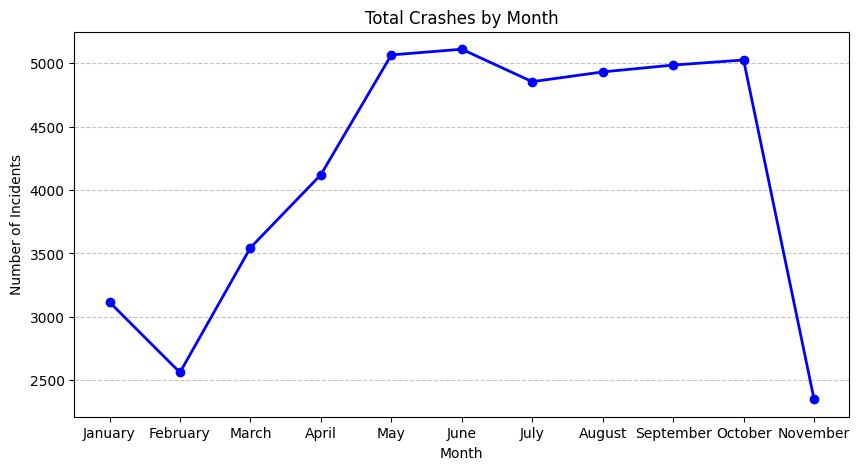

In [106]:
#1. Line chart showing the flow of time

plt.figure(figsize=(10, 5))
monthly_counts = cleaned_df["CRASH_DATE_TIME"].dt.month_name().value_counts()  #dates to month names convert and count

months_order = ["January", "February", "March", "April", "May", "June",
                "July", "August", "September", "October", "November", "December"]
monthly_counts = monthly_counts.reindex(months_order).dropna()
#took the CRASH_DATE_TIME column and extract just the name of the month. Thencounted how many crashes happen in each of this months.

plt.plot(monthly_counts.index, monthly_counts.values, marker='o', color='blue', linewidth=2)
plt.title("Total Crashes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.grid(axis="y", linestyle="--", alpha=0.75)
plt.show()

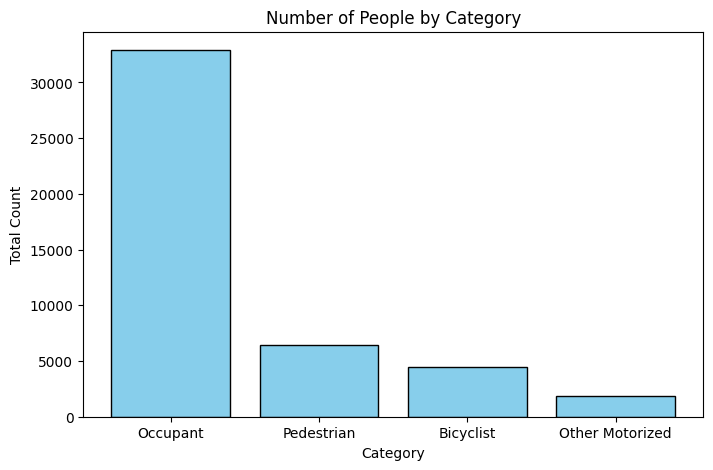

In [107]:
#2.Bar chart for easy comparison of gruops

plt.figure(figsize=(8, 5))
person_type_counts = cleaned_df["PERSON_TYPE"].value_counts()  #looked at the PERSON_TYPE colunm and count occurrences of Driver, Passenger,Pedestrian and so on
plt.bar(person_type_counts.index, person_type_counts.values, color="skyblue", edgecolor="black")
plt.title("Number of People by Category")
plt.xlabel("Category")
plt.ylabel("Total Count")
plt.show()

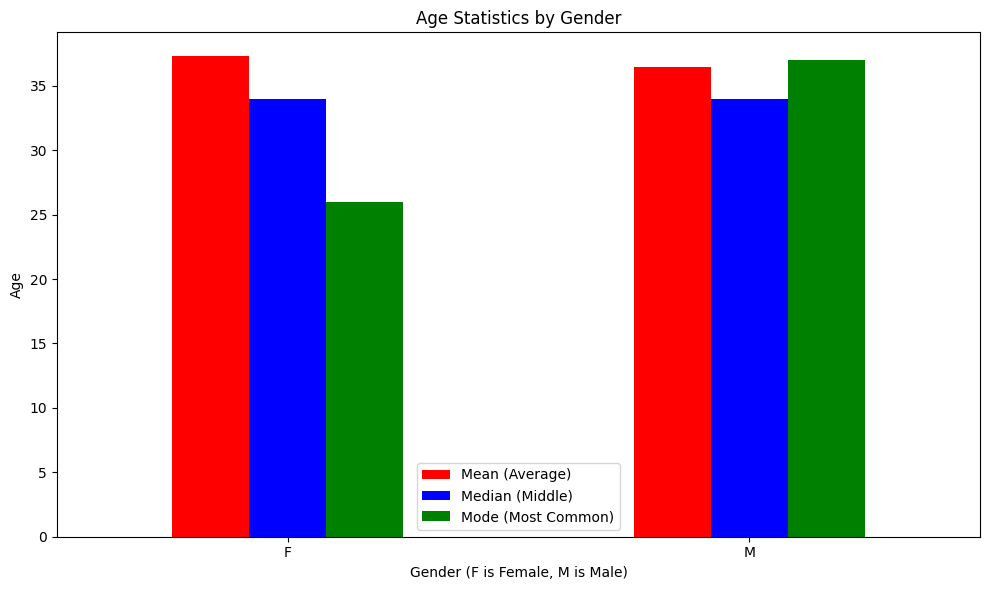

In [108]:
age_stats = nyc.crashes_by_age_sex()

#create the bar chart and use plot(kind="bar") to turn a table into a chart
age_stats.plot(kind="bar", figsize=(10, 6), color=["red", "blue", "green"])

plt.title("Age Statistics by Gender")
plt.xlabel("Gender (F is Female, M is Male)")
plt.ylabel("Age")

plt.xticks(rotation=0)

plt.legend(["Mean (Average)", "Median (Middle)", "Mode (Most Common)"])
plt.tight_layout()

plt.show()

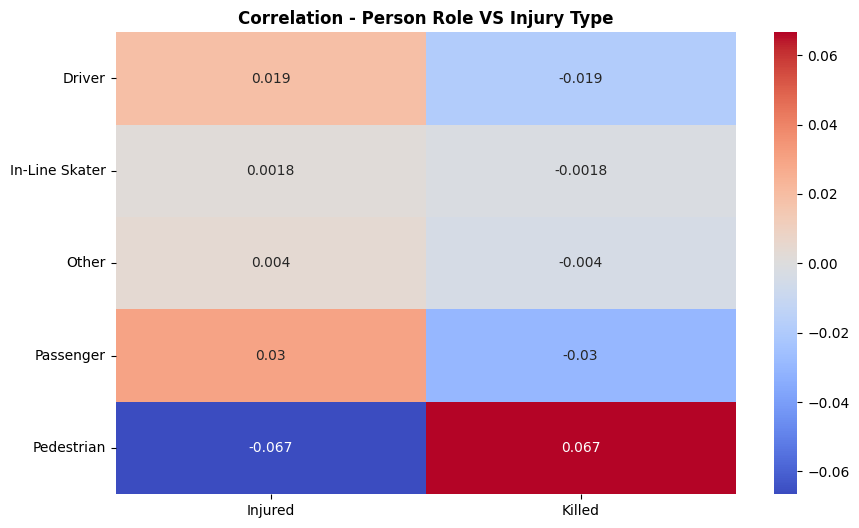

In [109]:
#4.Correlation between persons role and injury
role_data = nyc.cor_role_injury()

role_data.index = role_data.index.str.replace("PED_ROLE_", "")
role_data.columns = role_data.columns.str.replace("PERSON_INJURY_", "")
#Plot the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(role_data, annot=True, cmap="coolwarm")

plt.yticks(rotation=0) #make Driver, Pedestriian and so on be horizontal and not vertical
#Adding title
plt.title("Correlation - Person Role VS Injury Type", fontweight="bold")
plt.show()

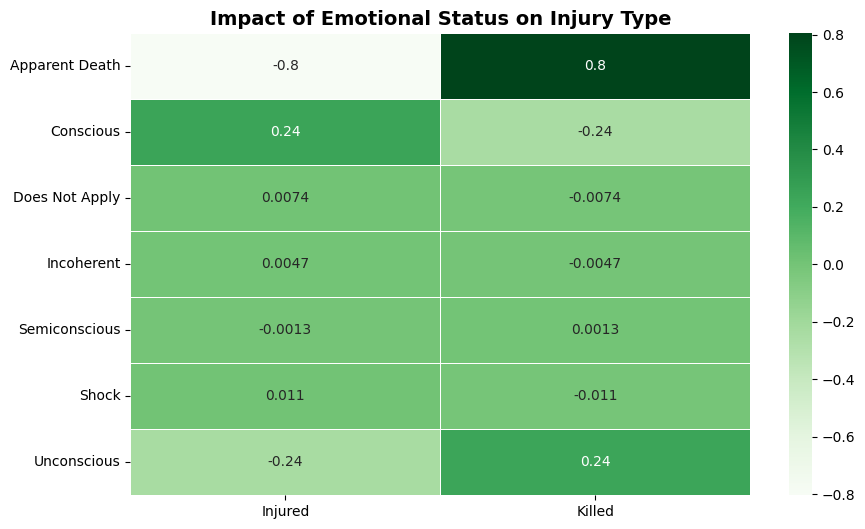

In [112]:
#5.Correlation between emotional status and injury

emo_corr = nyc.cor_emotional_status_injury()

emo_corr.index = emo_corr.index.str.replace("EMOTIONAL_STATUS_", "")
emo_corr.columns = emo_corr.columns.str.replace("PERSON_INJURY_", "")

#create the seaborn hetmap
plt.figure(figsize=(10, 6))

sns.heatmap(emo_corr, annot=True, cmap="Greens", linewidths=0.7)

plt.title("Impact of Emotional Status on Injury Type", fontsize=14, fontweight="bold")
plt.show()


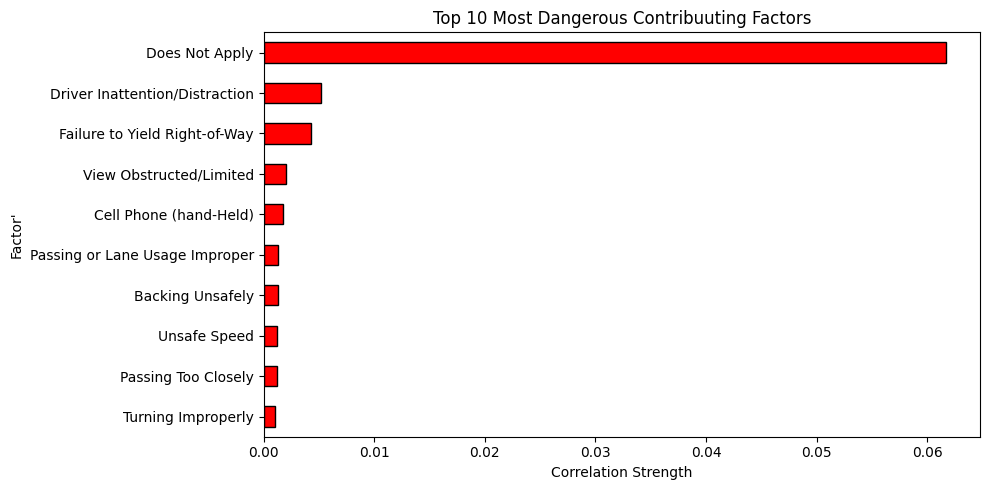

In [111]:
#6. corredlation between injury and factor
factor_data = nyc.cor_factor_injury()
factor_data.index = factor_data.index.str.replace("CONTRIBUTING_FACTOR_1_", "")

top_10_factors = factor_data.iloc[:, 0].sort_values(ascending=True).tail(10)

#create horizontal bar chart
plt.figure(figsize=(10,5))
top_10_factors.plot(kind="barh", color="red", edgecolor="black")

plt.title("Top 10 Most Dangerous Contribuuting Factors")
plt.xlabel("Correlation Strength")
plt.ylabel("Factor'")

plt.tight_layout()
plt.show()